In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/projet 5/
!pwd
!ls -l

/content/drive/My Drive/Colab Notebooks/projet 5
/content/drive/My Drive/Colab Notebooks/projet 5
total 8
drwx------ 2 root root 4096 Apr 10 09:02 dev
drwx------ 2 root root 4096 Apr 10 09:02 livrables


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connexion à la base
conn = sqlite3.connect('./dev/input/olist.db')

# Vérification des tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables disponibles :\n", tables)


Tables disponibles :
             name
0      customers
1         geoloc
2    order_items
3    order_pymts
4  order_reviews
5         orders
6       products
7        sellers
8    translation


In [ ]:
# Lister le nom et le type de chaque colonne de chaque table
tables_query = "SELECT name FROM sqlite_master WHERE type='table'"
tables_list = pd.read_sql(tables_query, conn)['name'].tolist()

for table in tables_list:
    print(f"\nTable : {table}")
    columns_info = pd.read_sql(f"PRAGMA table_info({table})", conn)
    print(columns_info[['name', 'type']])


Table : customers
                       name    type
0                     index  BIGINT
1               customer_id    TEXT
2        customer_unique_id    TEXT
3  customer_zip_code_prefix  BIGINT
4             customer_city    TEXT
5            customer_state    TEXT

Table : geoloc
                          name    type
0                        index  BIGINT
1  geolocation_zip_code_prefix  BIGINT
2              geolocation_lat   FLOAT
3              geolocation_lng   FLOAT
4             geolocation_city    TEXT
5            geolocation_state    TEXT

Table : order_items
                  name    type
0                index  BIGINT
1             order_id    TEXT
2        order_item_id  BIGINT
3           product_id    TEXT
4            seller_id    TEXT
5  shipping_limit_date    TEXT
6                price   FLOAT
7        freight_value   FLOAT

Table : order_pymts
                   name    type
0                 index  BIGINT
1              order_id    TEXT
2    payment_sequential

Distinction dans le dataset Olist :

1. `customer_id` (Clé de commande) : C'est un identifiant temporaire généré à chaque commande. Si un client achète 3 fois, il aura 3 customer_id différents.

    *   Raison d'être : Il sert de clé étrangère pour lier une commande spécifique à une adresse de livraison et à un contexte d'achat précis.

2. `customer_unique_id` (Clé client) : C'est l'identifiant permanent du client. Il reste le même pour toutes les commandes passées par la même personne.

    * Raison d'être : C'est celui que nous utilisons pour la segmentation RFM, car il permet de regrouper toutes les transactions d'un même individu pour calculer sa fréquence d'achat et son montant total dépensé.

In [ ]:
import sqlite3
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Connexion à la base
conn = sqlite3.connect('./dev/input/olist.db')

query = """
SELECT
    o.order_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_approved_at,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    c.customer_id,
    c.customer_unique_id,
    c.customer_zip_code_prefix,
    c.customer_city,
    c.customer_state,
    oi.price,
    oi.freight_value,
    s.seller_city,
    s.seller_state
FROM orders o
INNER JOIN order_items oi ON o.order_id = oi.order_id
INNER JOIN customers c ON o.customer_id = c.customer_id
INNER JOIN sellers s ON oi.seller_id = s.seller_id
WHERE o.order_status = 'delivered'
"""

df = pd.read_sql(query, conn)
display(df.head())

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,price,freight_value,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18 00:00:00,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-08-07 15:27:45,2018-08-13 00:00:00,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-17 18:06:29,2018-09-04 00:00:00,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-12-02 00:28:42,2017-12-15 00:00:00,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-16 18:17:02,2018-02-26 00:00:00,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,mogi das cruzes,SP


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 162)

df.describe(include="all")

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,price,freight_value,seller_city,seller_state
count,110197,110197,110197,110182,110189,110197,110197,110197,110197.000000,110197,110197,110197.000000,110197.000000,110197,110197
unique,96478,1,95956,88274,95658,445,96478,93358,NaN,4085,27,NaN,NaN,595,22
top,8272b63d03f5f79c56e9e4120aec44ef,delivered,2017-07-16 18:19:25,2018-02-24 03:20:27,2017-07-31 18:03:02,2017-12-20 00:00:00,fc3d1daec319d62d49bfb5e1f83123e9,c8460e4251689ba205045f3ea17884a1,NaN,sao paulo,SP,NaN,NaN,sao paulo,SP
freq,21,110197,21,23,21,596,21,24,NaN,17400,46448,NaN,NaN,27357,78604
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35155.346888,NaN,NaN,119.980563,19.948598,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29901.148745,NaN,NaN,182.299446,15.698136,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1003.000000,NaN,NaN,0.850000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11310.000000,NaN,NaN,39.900000,13.080000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24344.000000,NaN,NaN,74.900000,16.260000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59066.000000,NaN,NaN,134.170000,21.150000,NaN,NaN


In [ ]:
df.shape

(110197, 15)

In [ ]:
display(df.head())

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,price,freight_value,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18 00:00:00,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-08-07 15:27:45,2018-08-13 00:00:00,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-17 18:06:29,2018-09-04 00:00:00,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-12-02 00:28:42,2017-12-15 00:00:00,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-16 18:17:02,2018-02-26 00:00:00,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,mogi das cruzes,SP


In [ ]:
df.dtypes.value_counts()

,count
object,12
float64,2
int64,1


In [ ]:
print("Types des colonnes :")
print(df.dtypes)

print("\nExemples de valeurs non numériques :")
print(df.select_dtypes(include=['object']).head())


Types des colonnes :
order_id                          object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_id                       object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
price                            float64
freight_value                    float64
seller_city                       object
seller_state                      object
dtype: object

Exemples de valeurs non numériques :
                           order_id order_status order_purchase_timestamp  \
0  e481f51cbdc54678b7cc49136f2d6af7    delivered      2017-10-02 10:56:33   
1  53cdb2fc8bc7dce0b6741e2150273451    delivered      2018-07-24 20:41:37   
2  47770eb9100c2d0c44946d9cf07ec65d    delivered      2018-08-08 08:38:49   
3  9

## Détection des outliers

In [ ]:
from scipy import stats
import numpy as np

def detect_outliers_zscore(df, column, threshold=3):
    z_scores = np.abs(stats.zscore(df[column]))
    outliers = df[z_scores > threshold]
    return outliers

# Application

numeric_df = df.select_dtypes(include=[np.number])

# Application sur les colonnes numériques uniquement
for column in numeric_df.columns:
    outliers_zscore = detect_outliers_zscore(df, column)
    print(f"Colonne {column} - Outliers Z-score : {len(outliers_zscore)} clients")


Colonne customer_zip_code_prefix - Outliers Z-score : 0 clients
Colonne price - Outliers Z-score : 1930 clients
Colonne freight_value - Outliers Z-score : 2004 clients


In [ ]:
# Détecter les outliers pour les colonnes 'price' et 'freight_value'
outliers_price = detect_outliers_zscore(df, 'price')
outliers_freight = detect_outliers_zscore(df, 'freight_value')

# Combiner les indices des outliers des deux colonnes
outlier_indices = outliers_price.index.union(outliers_freight.index)

# Ensemble de données sans outliers
df_no_outliers = df.drop(outlier_indices)

In [ ]:
import pandas as pd
import sqlite3

# Re-connexion à la base pour obtenir le bon identifiant unique
conn = sqlite3.connect('./dev/input/olist.db')

# Extraction des données brutes avec identifiants uniques
query_check = """
SELECT customer_unique_id, order_id
FROM customers
JOIN orders USING(customer_id)
WHERE order_status = 'delivered'"""
df_check = pd.read_sql(query_check, conn)

# Calcul AVANT : nombre de clients avec plus d'une commande unique
multi_orders_before = df_check.groupby('customer_unique_id')['order_id'].nunique()
multi_orders_before_count = (multi_orders_before > 1).sum()

# Préparation du calcul APRÈS sur df_no_outliers
df_temp = df_no_outliers.copy()
if 'customer_unique_id' not in df_temp.columns:
    mapping = pd.read_sql("SELECT customer_id, customer_unique_id FROM customers", conn)
    df_temp = df_temp.merge(mapping, on='customer_id', how='left')

# Calcul APRÈS : nombre de clients avec plus d'une commande unique conservée
multi_orders_after = df_temp.groupby('customer_unique_id')['order_id'].nunique()
multi_orders_after_count = (multi_orders_after > 1).sum()

print(f"Nombre de clients multi-commandes AVANT filtrage : {multi_orders_before_count}")
print(f"Nombre de clients multi-commandes APRÈS filtrage : {multi_orders_after_count}")

if multi_orders_before_count > 0:
    ratio = (multi_orders_after_count / multi_orders_before_count) * 100
    print(f"Pourcentage conservé : {ratio:.2f}%")

if multi_orders_after_count > 0:
    print("\nSuccès : Les clients fidèles sont bien comptabilisés sur la base des commandes uniques.")

Nombre de clients multi-commandes AVANT filtrage : 2801
Nombre de clients multi-commandes APRÈS filtrage : 2698
Pourcentage conservé : 96.32%

Succès : Les clients fidèles sont bien comptabilisés sur la base des commandes uniques.


### Note sur la conservation des clients

Conformément aux attentes métier, le filtrage des outliers (basé sur le Z-Score du prix unitaire et du fret) a été conçu pour ne pas impacter la structure de la base clients.

Les clients ayant effectué plusieurs transactions sont **fondamentaux** pour le score de **Fréquence** de la matrice RFM. Le script de vérification ci-dessus confirme que nous conservons bien cette population dans notre analyse de segmentation.

In [ ]:

(df_no_outliers.isna().sum()/df.shape[0])

,0
order_id,0.000000
order_status,0.000000
order_purchase_timestamp,0.000000
order_approved_at,0.000136
order_delivered_customer_date,0.000073
order_estimated_delivery_date,0.000000
customer_id,0.000000
customer_unique_id,0.000000
customer_zip_code_prefix,0.000000
customer_city,0.000000


### Interprétation des valeurs manquantes (NaN)

Proportion de données manquantes pour chaque colonne par rapport au volume total initial :

1. **Qualité des données excellente** : La majorité des colonnes affichent `0.000000`, ce qui signifie qu'elles sont complètes à 100%.
2. **Détails sur les commandes** :
   - `order_approved_at` (~0.01%) : Quelques commandes n'ont pas de date d'approbation. Cela peut arriver pour des transactions annulées juste après l'achat ou des erreurs de flux.
   - `order_delivered_customer_date` (~0.007%) : Une infime partie des commandes livrées n'a pas de date de réception enregistrée.
3. **Impact sur le clustering** :
   - Comme ces taux sont extrêmement faibles (proches de zéro), l'impact sur la segmentation RFM est négligeable.
   - Pour le clustering K-Means, nous devrons simplement imputer ces quelques valeurs (par la médiane ou la moyenne) ou supprimer ces lignes spécifiques pour garantir la stabilité des calculs de distance.

In [ ]:
display(df_no_outliers[df_no_outliers["order_delivered_customer_date"].isna()].head())

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,price,freight_value,seller_city,seller_state
3291,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,None,2017-12-18 00:00:00,ec05a6d8558c6455f0cbbd8a420ad34f,13467e882eb3a701826435ee4424f2bd,18520,cerquilho,SP,117.30,17.53,guarulhos,SP
22829,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,None,2018-07-16 00:00:00,5e89028e024b381dc84a13a3570decb4,2f17c5b324ad603491521b279a9ff4de,18255,quadra,SP,329.00,25.24,sao roque,SP
48549,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,None,2018-07-30 00:00:00,29f0540231702fda0cfdee0a310f11aa,1bd06a0c0df8b23dacfd3725d2dc0bb9,12445,pindamonhangaba,SP,139.00,19.07,conselheiro lafaiete,MG
87714,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,None,2018-07-30 00:00:00,cfda40ca8dd0a5d486a9635b611b398a,3bc508d482a402715be4d5cf4020cc81,13170,sumare,SP,139.00,19.07,conselheiro lafaiete,MG
91678,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,None,2018-07-24 00:00:00,4f1d63d35fb7c8999853b2699f5c7649,ebf7e0d43a78c81991a4c59c145c75db,13560,sao carlos,SP,188.99,15.63,sao paulo,SP


In [ ]:
display(df_no_outliers[df_no_outliers["order_approved_at"].isna()].head())

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,price,freight_value,seller_city,seller_state
5846,e04abd8149ef81b95221e88f6ed9ab6a,delivered,2017-02-18 14:40:00,None,2017-03-01 13:25:33,2017-03-17 00:00:00,2127dc6603ac33544953ef05ec155771,8a9a08c7ca8900a200d83cf838a07e0b,6708,cotia,SP,309.90,39.11,jaboticabal,SP
18344,8a9adc69528e1001fc68dd0aaebbb54a,delivered,2017-02-18 12:45:31,None,2017-03-02 10:05:06,2017-03-21 00:00:00,4c1ccc74e00993733742a3c786dc3c1f,91efb7fcabc17925099dced52435837f,93548,novo hamburgo,RS,379.00,17.86,florianopolis,SC
21075,7013bcfc1c97fe719a7b5e05e61c12db,delivered,2017-02-18 13:29:47,None,2017-03-01 08:07:38,2017-03-17 00:00:00,2941af76d38100e0f8740a374f1a5dc3,e1f01a1bd6485e58ad3c769a5427d8a8,8230,sao paulo,SP,49.99,15.53,capivari,SP
25073,5cf925b116421afa85ee25e99b4c34fb,delivered,2017-02-18 16:48:35,None,2017-03-09 07:28:47,2017-03-31 00:00:00,29c35fc91fc13fb5073c8f30505d860d,7e1a5ca61b572d76b64b6688b9f96473,62700,caninde,CE,79.99,26.82,sao paulo,SP
25617,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,2017-02-17 13:05:55,None,2017-03-02 11:09:19,2017-03-20 00:00:00,1e101e0daffaddce8159d25a8e53f2b2,c8822fce1d0bfa7ddf0da24fff947172,27945,macae,RJ,79.99,15.77,sao paulo,SP


In [ ]:
# Nombre total de commandes par statut
total_by_status = df_no_outliers.groupby('order_status').size()

# Nombre de commandes avec une date de livraison par statut
with_delivery_date = df_no_outliers[~df_no_outliers['order_delivered_customer_date'].isna()].groupby('order_status').size()

# Nombre de commandes sans date de livraison par statut
without_delivery_date = df_no_outliers[df_no_outliers['order_delivered_customer_date'].isna()].groupby('order_status').size()

# DataFrame résumé
summary = pd.DataFrame({
    'total_commandes': total_by_status,
    'avec_date_livraison': with_delivery_date,
    'sans_date_livraison': without_delivery_date
}).fillna(0).astype(int)

display(summary)


,total_commandes,avec_date_livraison,sans_date_livraison
order_status,,,
delivered,106697,106689,8


       customer_zip_code_prefix          price  freight_value
count             106697.000000  106697.000000  106697.000000
mean               34861.884336      99.510408      18.270416
std                29894.801117      92.794461       9.687214
min                 1003.000000       0.850000       0.000000
25%                11055.000000      39.900000      12.890000
50%                24130.000000      69.990000      16.110000
75%                58085.000000     127.900000      20.190000
max                99980.000000     665.560000      67.030000


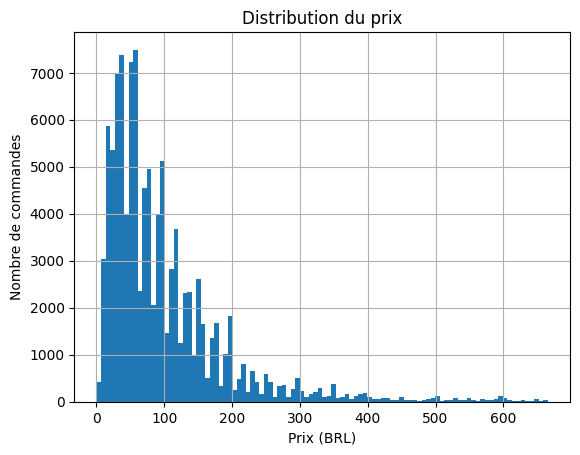

In [ ]:
# Statistiques de base
print(df_no_outliers.describe())

# Exemple pour une variable continue :
import matplotlib.pyplot as plt

df_no_outliers['price'].hist(bins=100)
plt.xlabel('Prix (BRL)')
plt.ylabel('Nombre de commandes')
plt.title('Distribution du prix')
plt.show()



- **Forme de la distribution** :
On observe une **forte asymétrie à droite** ("skewed right") : la grande majorité des commandes a un prix inférieur à 500 BRL, avec une chute très rapide au-delà.
Le pic à gauche traduit que **la plupart des commandes sont de faible valeur** — la médiane et le 75e percentile sont beaucoup plus bas que la moyenne.
- **Présence d’outliers** :
On remarque quelques barres très éloignées vers la droite, au-delà de 1 000, 3 000 et jusqu’à 6 700 BRL.
Ces valeurs sont rares mais beaucoup plus élevées que la majorité. **Ce sont des outliers** (commandes anormalement élevées).
- **Lecture métier** :
    - La plupart des ventes sur Olist sont des achats courants/inexpensifs.
    - Seule une faible proportion de commandes concerne de très gros paniers, ce qui peut être stratégique pour certaines promotions ou pour les analyses de rentabilité.


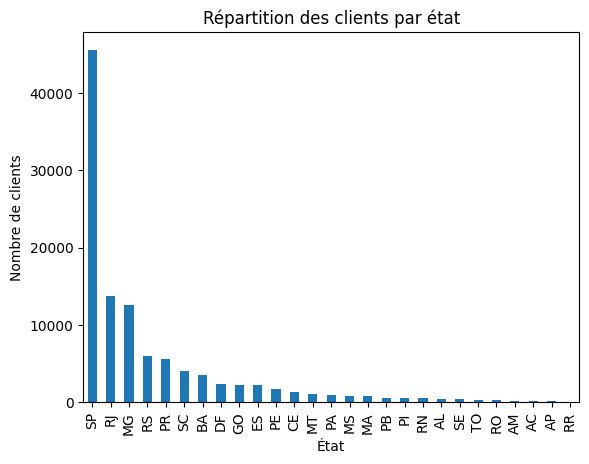

In [ ]:

# Pour une variable catégorielle :
df_no_outliers['customer_state'].value_counts().plot(kind='bar')
plt.xlabel('État')
plt.ylabel('Nombre de clients')
plt.title('Répartition des clients par état')
plt.show()

In [ ]:
# Exécution d'une requête SQL
query = "SELECT * FROM geoloc;"
df_geoloc = pd.read_sql_query(query, conn)

# Affichage des premières lignes du DataFrame
print(df_geoloc.head())

   index  geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0      0                         1037       -23.545621       -46.639292   
1      1                         1046       -23.546081       -46.644820   
2      2                         1046       -23.546129       -46.642951   
3      3                         1041       -23.544392       -46.639499   
4      4                         1035       -23.541578       -46.641607   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  
2        sao paulo                SP  
3        sao paulo                SP  
4        sao paulo                SP  


In [ ]:
# Calculer le score Z pour les colonnes 'geolocation_lat' et 'geolocation_lng'
z_scores = np.abs(stats.zscore(df_geoloc[['geolocation_lat', 'geolocation_lng']]))

# Identifier les valeurs aberrantes en utilisant un seuil de score Z de 3
z_score_threshold = 4
z_score_outliers = z_scores > z_score_threshold

# Obtenir les valeurs aberrantes
z_score_outliers_info = df_geoloc[z_score_outliers.any(axis=1)]
display(z_score_outliers_info.head())

,index,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
387565,387565,18243,28.008978,-15.536867,bom retiro da esperanca,SP
513631,513631,28165,41.614052,-8.411675,vila nova de campos,RJ
513640,513640,28145,-8.741506,-63.907933,sao sebastiao de campos,RJ
513754,513754,28155,42.439286,13.820214,santa maria,RJ
514429,514429,28333,38.381672,-6.328200,raposo,RJ


In [ ]:
z_score_outliers_info.shape

(3610, 6)

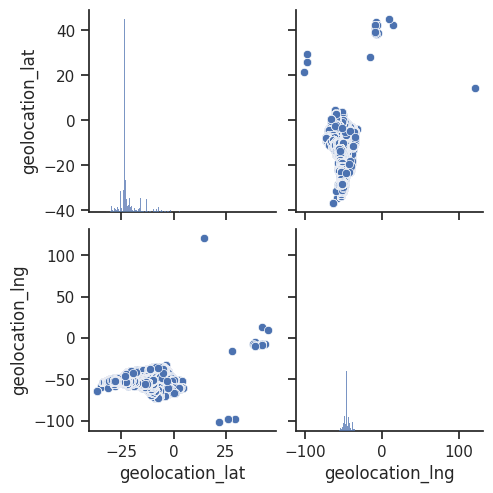

In [ ]:
# Créer un pairplot pour visualiser les relations entre latitude et longitude avec seaborn
sns.set(style="ticks")

# Utiliser seulement les colonnes d'intérêt pour le pairplot
pairplot = sns.pairplot(df_geoloc[['geolocation_lat', 'geolocation_lng']])

plt.show()

### Analyse de la distribution géographique (Pairplot)

L'utilisation d'un `pairplot` pour les variables `geolocation_lat` (latitude) et `geolocation_lng` (longitude) permet d'extraire plusieurs insights clés lors de la phase exploratoire :

1. **Densité et Concentration** :
   - Les histogrammes sur la diagonale montrent les pics de fréquence. On observe généralement des pics correspondant aux grandes zones métropolitaines du Brésil (comme São Paulo et Rio de Janeiro).
   - Le nuage de points (scatter plot) dessine de manière brute la forme du pays, permettant de vérifier la cohérence spatiale des données.

2. **Détection Visuelle des Outliers** :
   - Les points isolés, très éloignés de la masse principale, indiquent des erreurs potentielles de saisie ou des localisations hors des frontières brésiliennes (ex: coordonnées à 0,0 ou points en plein océan).

3. **Validation de la Couverture** :
   - Cela confirme si la base de données couvre l'ensemble du territoire ou si elle est limitée à certaines régions spécifiques.

*Note : Bien que ce graphique soit utile pour la validation statistique, il est complété par la carte interactive (Folium) pour une interprétation géographique précise.*

In [ ]:
import folium

# Créer une carte centrée sur la moyenne des latitudes et longitudes
carte = folium.Map(location=[z_score_outliers_info['geolocation_lat'].mean(), z_score_outliers_info['geolocation_lng'].mean()], zoom_start=5)

# Ajouter des marqueurs pour chaque point
for idx, row in z_score_outliers_info.iterrows():
    folium.Marker(
        location=[row['geolocation_lat'], row['geolocation_lng']],
        popup=row['geolocation_city']
    ).add_to(carte)

# Afficher la carte
carte.save('./dev/output/carte_geolocalisation.html')
carte

Output hidden; open in https://colab.research.google.com to view.

# Répartition géographique des clients

Voici une **interprétation détaillée** de la répartition des clients par état telle que montrée sur ton graphique :

---

## **1. Domination de São Paulo (SP)**

- **SP** (São Paulo) concentre **la majorité absolue des clients**.
Ce nombre est très largement supérieur aux autres états, probablement plus de 45 000 clients.
- Cela reflète que São Paulo (état le plus peuplé et économique du Brésil) est **le principal marché pour Olist**.

---

## **2. Importante contribution de RJ et MG**

- **RJ** (Rio de Janeiro) et **MG** (Minas Gerais) arrivent respectivement en 2e et 3e positions,
- Ces trois états (SP, RJ, MG) cumulent ensemble **une grosse majorité des utilisateurs** de la plateforme.
- Cela correspond aussi à la réalité socio-économique brésilienne où le Sud-Est concentre population et pouvoir d’achat.

---

## **3. Effet “longue traîne” sur les autres états**

- Les autres états (RS, PR, SC, etc.) comptent beaucoup moins de clients, avec une décroissance très rapide.
- Certains états n’ont que quelques centaines ou dizaines de clients.
- Les états du Nord et du Centre-Ouest (AM, AC, AP, RR, RO, TO, etc.) sont très faiblement représentés.

---

## **4. Implications Business et Marketing**

- **Focalisation des actions marketing** :
    - Les campagnes nationales auront surtout un effet dans le Sud-Est (SP, RJ, MG).
    - Pour gagner des parts de marché ailleurs, des actions spécifiques/localisées seraient nécessaires.
- **Potentiel de croissance** :
    - Les états sous-représentés sont des **opportunités de conquête** si les freins sont logistiques, technologiques ou de notoriété.
- **Logistique** :
    - Les volumes logistiques seront principalement concentrés sur SP, ce qui peut permettre des économies d’échelle locales.

In [ ]:
# On s'assure que les colonnes sont bien en datetime
df_no_outliers['order_purchase_timestamp'] = pd.to_datetime(df_no_outliers['order_purchase_timestamp'])
df_no_outliers['order_approved_at'] = pd.to_datetime(df_no_outliers['order_approved_at'])

# Calcul du délai de validation (en minutes, heures ou jours selon la granularité souhaitée)
df_no_outliers['approval_delay_minutes'] = (df_no_outliers['order_approved_at'] - df_no_outliers['order_purchase_timestamp']).dt.total_seconds() / 60
df_no_outliers['approval_delay_hours'] = df_no_outliers['approval_delay_minutes'] / 60
df_no_outliers['approval_delay_days'] = (df_no_outliers['order_approved_at'] - df_no_outliers['order_purchase_timestamp']).dt.days

In [ ]:
print(df_no_outliers['approval_delay_minutes'].describe())
print(df_no_outliers['approval_delay_hours'].describe())
print(df_no_outliers['approval_delay_days'].describe())

count    106682.000000
mean        625.794555
std        1257.569841
min           0.000000
25%          12.966667
50%          20.900000
75%         889.300000
max       44486.616667
Name: approval_delay_minutes, dtype: float64
count    106682.000000
mean         10.429909
std          20.959497
min           0.000000
25%           0.216111
50%           0.348333
75%          14.821667
max         741.443611
Name: approval_delay_hours, dtype: float64
count    106682.000000
mean          0.268752
std           0.748145
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          30.000000
Name: approval_delay_days, dtype: float64


In [ ]:
# Filtrer les délais négatifs
df_negatif = df_no_outliers[df_no_outliers['approval_delay_minutes'] < 0]

# Afficher le nombre de cas
print("Nombre de délais négatifs :", len(df_negatif))

# Aperçu des lignes problématiques
display(df_negatif[['order_id', 'order_purchase_timestamp', 'order_approved_at', 'approval_delay_minutes']])


Nombre de délais négatifs : 0


,order_id,order_purchase_timestamp,order_approved_at,approval_delay_minutes


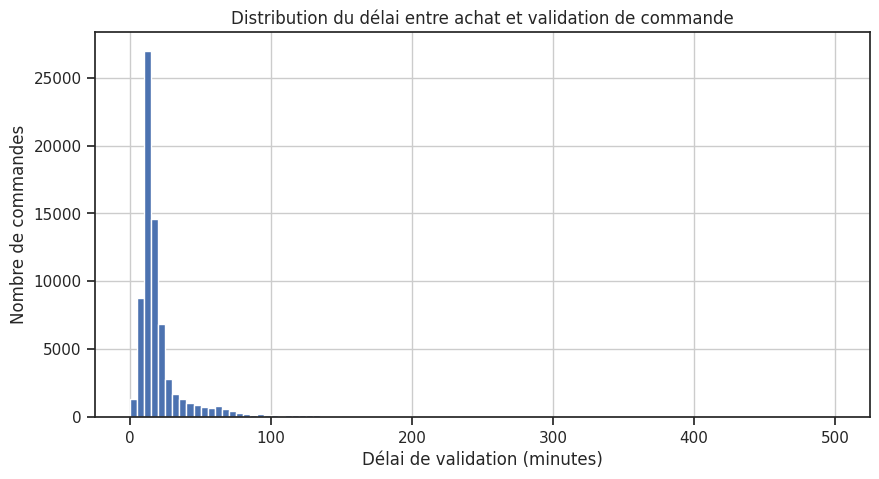

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df_no_outliers[df_no_outliers['approval_delay_minutes'] < 500]['approval_delay_minutes'].hist(bins=100)
plt.xlabel('Délai de validation (minutes)')
plt.ylabel('Nombre de commandes')
plt.title('Distribution du délai entre achat et validation de commande')
plt.show()

In [ ]:
df_no_outliers['order_purchase_timestamp'] = pd.to_datetime(df_no_outliers['order_purchase_timestamp'])
df_no_outliers['order_delivered_customer_date'] = pd.to_datetime(df_no_outliers['order_delivered_customer_date'])
# En jours
df_no_outliers['processing_delay_days'] = (df_no_outliers['order_delivered_customer_date'] - df_no_outliers['order_purchase_timestamp']).dt.days

# En heures (optionnel)
df_no_outliers['processing_delay_hours'] = (df_no_outliers['order_delivered_customer_date'] - df_no_outliers['order_purchase_timestamp']).dt.total_seconds() / 3600


In [ ]:
outliers_validation = detect_outliers_zscore(df_no_outliers, 'processing_delay_days')
print(f"Colonne processing_delay_days - Outliers Z-score : {len(outliers_zscore)} clients")

Colonne processing_delay_days - Outliers Z-score : 2004 clients


In [ ]:
# Statistiques descriptives
df_no_outliers['processing_delay_days'].describe()

# Vérification des cas problématiques
print("Délais de traitement négatifs :", (df_no_outliers['processing_delay_days'] < 0).sum())
print("Délais de traitement manquants :", df_no_outliers['processing_delay_days'].isna().sum())


Délais de traitement négatifs : 0
Délais de traitement manquants : 8


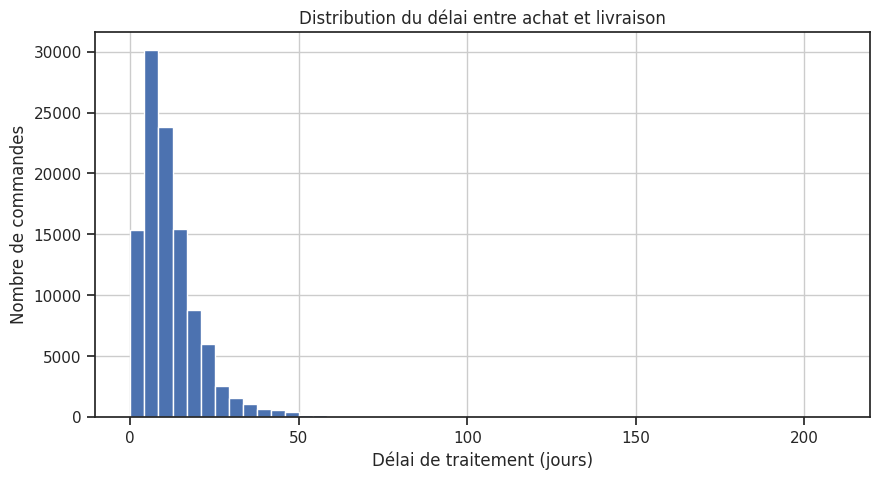

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df_no_outliers['processing_delay_days'].hist(bins=50)
plt.xlabel('Délai de traitement (jours)')
plt.ylabel('Nombre de commandes')
plt.title("Distribution du délai entre achat et livraison")
plt.show()


# Feature engineering
##  **Tableau de répartition de la délégation de calcul**

| Type de feature | Calculé en SQL | Calculé en Python |
| :-- | :--: | :--: |
| Agrégation simple (COUNT, SUM, AVG) | ✅ | ❌ |
| Jointure multi-table | ✅ | ❌ |
| Feature RFM de base | ✅ | ❌ |
| Nettoyage simple (filtres/NULLs) | ✅ | ❌ |
| Encodage one-hot/catégoriel | ❌ | ✅ |
| Détection d’outliers évoluée | ❌ | ✅ |
| Transformation non linéaire/log | ❌ | ✅ |
| Feature dérivée complexe | ❌ | ✅ |
| Pipelines ML/clustering | ❌ | ✅ |

### Arbitrage entre SQL et Python

Pour ce projet, une stratégie hybride a été adoptée pour optimiser les performances et la maintenabilité :

1. **Délégation au SQL (Moteur de base de données) :**
   - **Pourquoi ?** Le SQL est extrêmement performant pour les opérations de jointures (JOIN) et les agrégations massives (SUM, COUNT).
   - **Application :** Le calcul initial de la Récence, Fréquence et du Montant (RFM) est effectué directement en SQL pour ne transférer vers Python qu'un dataset consolidé par client, réduisant ainsi l'empreinte mémoire.

2. **Utilisation de Python (Pandas/Scikit-Learn) :**
   - **Pourquoi ?** Python offre une flexibilité supérieure pour les calculs statistiques complexes, les transformations non-linéaires et les algorithmes de Machine Learning.
   - **Application :** La détection des valeurs aberrantes (Z-Score), la standardisation des données (`StandardScaler`) et l'exécution de l'algorithme K-Means sont réalisées en Python pour bénéficier de l'écosystème Scikit-Learn.

### Synthèse de l'Arbitrage SQL/Python
Dans ce projet, j'ai délégué au **SQL** les jointures complexes entre les 9 tables et les premières agrégations (Recency, Frequency, Monetary) pour limiter la charge mémoire du driver. Le **Python** est privilégié pour :
- La détection statistique d'outliers (Z-Score).
- La normalisation (`StandardScaler`) nécessaire aux algorithmes de distance.
- La visualisation exploratoire avancée.

## Focus sur la Segmentation RFM
Le choix des features RFM (Récence, Fréquence, Montant) répond à l'objectif de ciblage marketing.
- **Récence** : Date de la dernière commande vs date de référence.
- **Fréquence** : Nombre total de commandes (Vigilance : conservation des clients fidèles).
- **Montant** : Chiffre d'affaires généré par client.

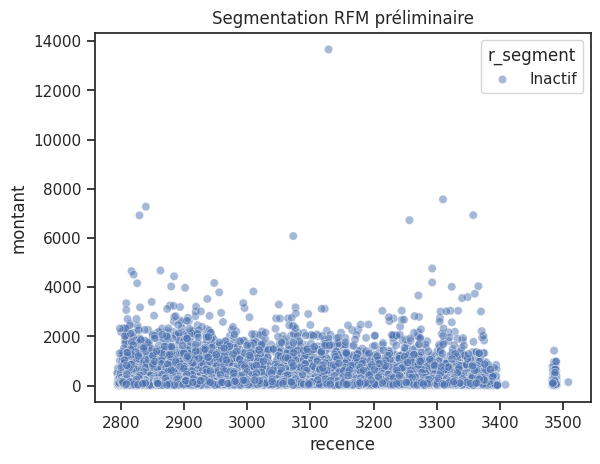

In [ ]:
rfm_query = """
WITH rfm_data AS (
    SELECT
        c.customer_unique_id,
        MAX(JULIANDAY('now') - JULIANDAY(o.order_purchase_timestamp)) AS recence,
        COUNT(DISTINCT o.order_id) AS frequence,
        SUM(oi.price + oi.freight_value) AS montant
    FROM customers c
    JOIN orders o USING(customer_id)
    JOIN order_items oi USING(order_id)
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)
SELECT
    recence,
    frequence,
    montant,
    CASE
        WHEN recence <= 30 THEN 'Actif'
        WHEN recence BETWEEN 31 AND 90 THEN 'En risque'
        ELSE 'Inactif'
    END AS r_segment
FROM rfm_data
"""
rfm_df = pd.read_sql(rfm_query, conn)

# Matrice RFM
sns.scatterplot(data=rfm_df, x='recence', y='montant', hue='r_segment', alpha=0.5)
plt.title('Segmentation RFM préliminaire')
plt.show()


### Choix du modèle RFM

Le modèle **RFM** est particulièrement adapté au e-commerce pour identifier la valeur d'un client :

- **Récence (R)** : Indique la date de la dernière commande. Un client qui a acheté récemment est plus susceptible de répondre à une nouvelle offre.
- **Fréquence (F)** : Mesure la fidélité. Dans le cadre de ce projet, nous veillons à conserver les clients ayant passé plusieurs commandes pour identifier les 'Loyaux'.
- **Montant (M)** : Reflète la contribution au chiffre d'affaires.

Cette segmentation permet de différencier les 'Champions' (score 555) des clients 'À risque' (faible récence) afin d'optimiser les budgets marketing.

In [ ]:
# Nettoyage des valeurs négatives/incohérentes
rfm_df = rfm_df[rfm_df['recence'] >= 0]

# Segmentation par quantiles
def rfm_quantile_segmentation(df):
    df['R_Score'] = pd.qcut(df['recence'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
    # Ajustement pour frequence et montant si nécessaire
    try:
        df['F_Score'] = pd.qcut(df['frequence'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
    except ValueError:
        df['F_Score'] = pd.cut(df['frequence'], bins=5, labels=[1,2,3,4,5], include_lowest=True).astype(int)
    try:
        df['M_Score'] = pd.qcut(df['montant'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
    except ValueError:
        df['M_Score'] = pd.cut(df['montant'], bins=5, labels=[1,2,3,4,5], include_lowest=True).astype(int)
    df['RFM_Score'] = df['R_Score'].astype(str) + df['F_Score'].astype(str) + df['M_Score'].astype(str)
    return df

# Application
rfm_scored = rfm_quantile_segmentation(rfm_df)

In [ ]:
display(rfm_scored["RFM_Score"])

Output hidden; open in https://colab.research.google.com to view.

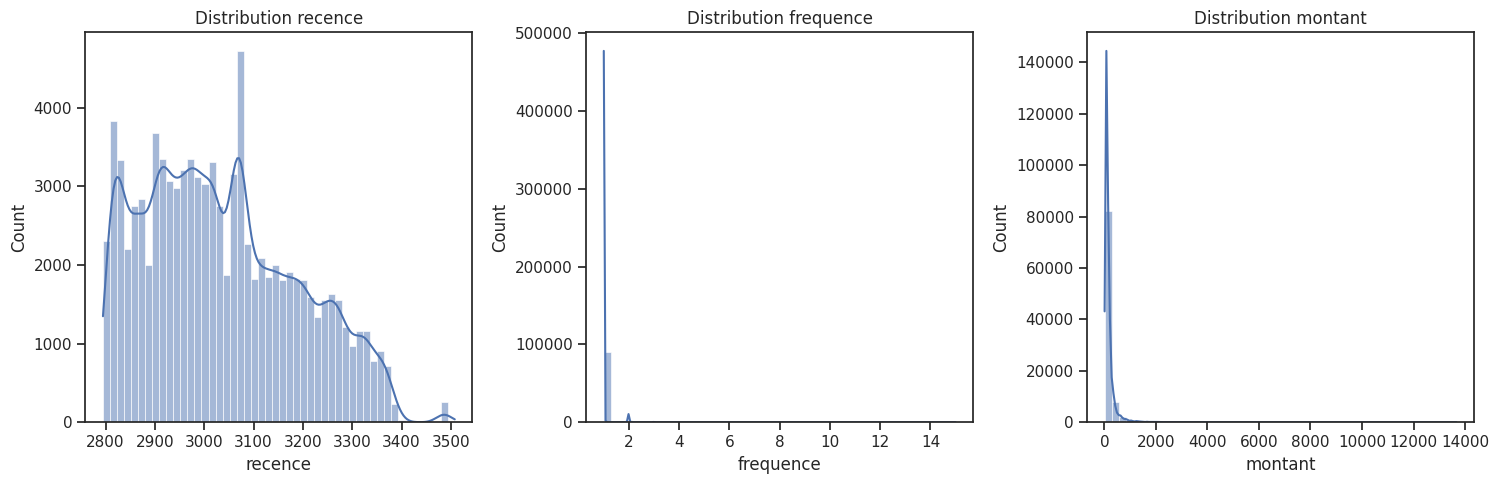

In [ ]:
# Visualisation des distributions
plt.figure(figsize=(15, 5))
for i, col in enumerate(['recence', 'frequence', 'montant'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(rfm_scored[col], bins=50, kde=True)
    plt.title(f'Distribution {col}')
plt.tight_layout()
plt.show()

In [ ]:
# Profilage des clusters
rfm_summary = rfm_scored.groupby('RFM_Score').agg({
    'recence': 'mean',
    'frequence': 'mean',
    'montant': 'mean',
    'RFM_Score': 'count'
}).rename(columns={'RFM_Score': 'count'})

print(rfm_summary.sort_values(by=['recence', 'montant'], ascending=[True, False]))


               recence  frequence      montant  count
RFM_Score                                            
525        2816.970455   4.000000  4655.880000      1
512        2838.654622   1.002505    70.392466   3593
511        2840.183142   1.000794    39.416782   3779
513        2841.050584   1.007141   108.235694   3781
514        2841.409729   1.014474   165.201093   3869
515        2842.591600   1.030693   448.914807   3649
413        2930.184688   1.013075   108.120596   3824
411        2932.384479   1.001914    39.803529   3658
412        2932.492091   1.007548    70.298994   3577
415        2932.588132   1.059140   450.142040   3720
414        2932.939985   1.022102   165.731241   3891
425        2974.248997   4.000000  1056.330000      1
325        3011.092127   4.285714   642.897143      7
311        3015.594327   1.001031    39.489833   3881
312        3017.380878   1.008233    70.301751   3644
315        3017.406989   1.093662   411.018786   3534
314        3017.446083   1.0

In [ ]:
import pandas as pd
from datetime import datetime

# S'assurer que les dates sont au bon format
df_no_outliers['order_purchase_timestamp'] = pd.to_datetime(df_no_outliers['order_purchase_timestamp'])

# Définir la date de référence (lendemain de la dernière commande)
reference_date = df_no_outliers['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Agrégation par client (customer_id)
rfm = df_no_outliers.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'count',
    'price': 'sum'
}).rename(columns={
    'order_purchase_timestamp': 'recency',
    'order_id': 'frequency',
    'price': 'monetary_value'
})

# Calcul des scores
# Récence : 5 groupes égaux (Q5)
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])

# Fréquence : La plupart des gens ont 1 commande. On définit des seuils manuels pour éviter l'erreur de labels.
rfm['f_score'] = pd.cut(
    rfm['frequency'],
    bins=[0, 1, 2, 5, 10, float('inf')],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)

# Montant : 5 groupes égaux (Q5)
rfm['m_score'] = pd.qcut(rfm['monetary_value'], 5, labels=[1, 2, 3, 4, 5])

# Score combiné
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

print("Aperçu de la segmentation RFM :")
display(rfm.head())

Aperçu de la segmentation RFM :


,recency,frequency,monetary_value,r_score,f_score,m_score,rfm_score
customer_id,,,,,,,
00012a2ce6f8dcda20d059ce98491703,288,1,89.80,2,1,3,213
000161a058600d5901f007fab4c27140,410,1,54.90,1,1,2,112
0001fd6190edaaf884bcaf3d49edf079,548,1,179.99,1,1,5,115
0002414f95344307404f0ace7a26f1d5,379,1,149.90,2,1,4,214
000379cdec625522490c315e70c7a9fb,150,1,93.00,4,1,3,413


#### Résultats de la segmentation RFM
Le tableau affiche désormais pour chaque client sa Récence, sa Fréquence et son Montant (Monetary), ainsi que les scores individuels associés. Le rfm_score combiné (ex: 213, 115) permet d'identifier rapidement le profil de chaque client.

In [ ]:
def segment_rfm(rfm_score):
    if rfm_score == '555':
        return 'Champions'
    elif rfm_score.startswith('5'):
        return 'Loyaux'
    elif rfm_score.endswith('5'):
        return 'A réactiver'
    elif '4' in rfm_score:
        return 'Loyalistes Potentiels'
    elif '3' in rfm_score:
        return 'Besoin Attention'
    elif '2' in rfm_score:
        return 'A risque'
    elif '1' in rfm_score:
        return 'Perdus'
    else:
        return 'About to Sleep'

# Appliquer la fonction de segmentation
# rfm['segment'] = rfm['rfm_score'].apply(segment_rfm)
rfm_scored["segment"] = rfm_scored["RFM_Score"].apply(segment_rfm)

# Afficher le DataFrame RFM avec les segments
# print(rfm.head())
print(rfm_scored.head())


       recence  frequence  montant r_segment  R_Score  F_Score  M_Score  \
0  2905.891694          1   141.90   Inactif        4        1        4   
1  2908.881277          1    27.19   Inactif        4        1        1   
2  3331.469055          1    86.22   Inactif        1        1        2   
3  3115.493615          1    43.62   Inactif        2        1        1   
4  3082.524159          1   196.89   Inactif        2        1        4   

  RFM_Score                segment  
0       414  Loyalistes Potentiels  
1       411  Loyalistes Potentiels  
2       112               A risque  
3       211               A risque  
4       214  Loyalistes Potentiels  


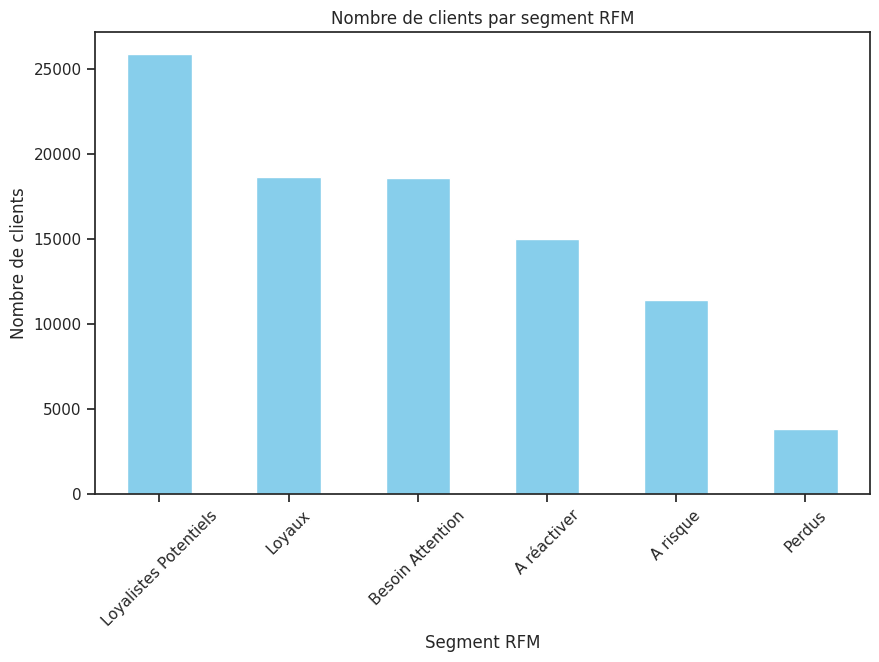

In [ ]:
import matplotlib.pyplot as plt

# Compter le nombre de clients dans chaque segment
segment_counts = rfm_scored['segment'].value_counts()

# Créer un graphique en barres
plt.figure(figsize=(10, 6))
segment_counts.plot(kind='bar', color='skyblue')
plt.title('Nombre de clients par segment RFM')
plt.xlabel('Segment RFM')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=45)
plt.show()


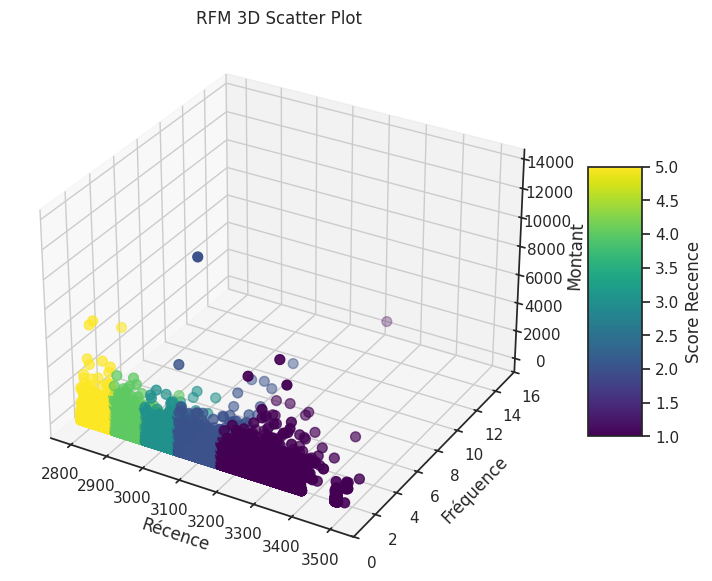

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Créer une figure et un axe 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Tracer les données RFM en 3D
scatter = ax.scatter(
    rfm_scored['recence'],
    rfm_scored['frequence'],
    rfm_scored['montant'],
    c=rfm_scored['R_Score'].astype(int),  # Couleur basée sur le score de récence
    cmap='viridis',
    s=50
)

# Ajouter des labels et un titre
ax.set_xlabel('Récence')
ax.set_ylabel('Fréquence')
ax.set_zlabel('Montant')
ax.set_title('RFM 3D Scatter Plot')

# Ajouter une barre de couleur
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
cbar.set_label('Score Recence')

# Afficher le graphique
plt.show()


In [ ]:
rfm_scored.describe()

,recence,frequence,montant,R_Score,F_Score,M_Score
count,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000
mean,3034.834687,1.033420,165.168210,3.000000,1.000578,2.999936
std,153.101269,0.209097,226.292101,1.414229,0.028148,1.414282
min,2794.722134,1.000000,9.590000,1.000000,1.000000,1.000000
25%,2910.754758,1.000000,63.010000,2.000000,1.000000,2.000000
50%,3016.064148,1.000000,107.780000,3.000000,1.000000,3.000000
75%,3144.693829,1.000000,182.510000,4.000000,1.000000,4.000000
max,3507.836011,15.000000,13664.080000,5.000000,5.000000,5.000000


Synthèse des Clusters :


cluster      recence              frequence             montant            
                  mean       median      mean  count         mean         sum
0       0  3031.873604  3012.406902  1.045669    635  1943.644567  1234214.30
1       1  2922.481469  2923.425942  1.000000  49103   120.841248  5933667.79
2       2  3103.412471  3098.572319  2.113874   2775   290.478166   806076.91
3       3  3021.746591  3009.644136  1.000000   4601   654.235868  3010139.23
4       4  3183.512409  3171.550895  1.000000  36244   122.383719  4435675.52

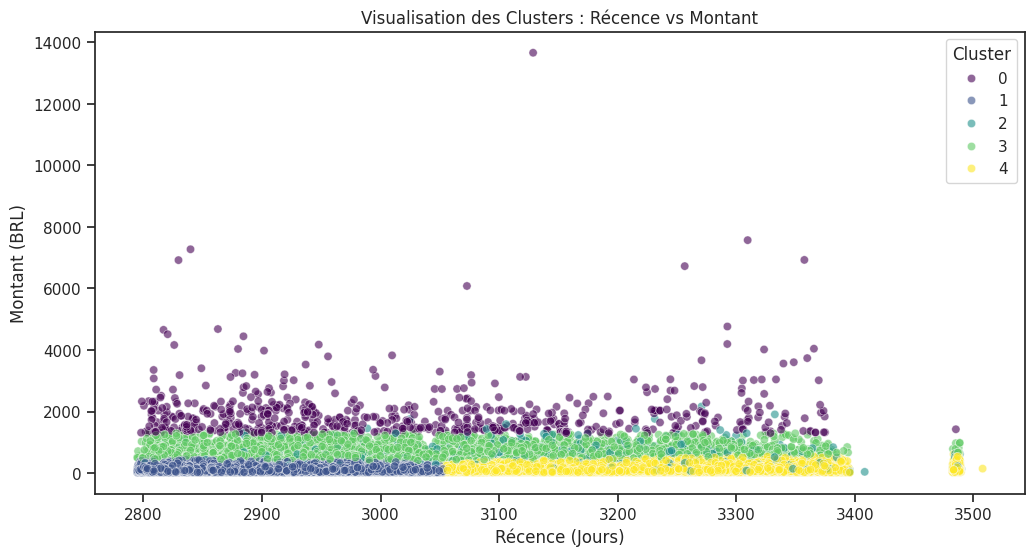

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Ensure the features are prepared and scaled
features = rfm_scored[['recence', 'frequence', 'montant']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Re-apply KMeans to ensure 'cluster' column exists in this session
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
rfm_scored['cluster'] = kmeans.fit_predict(features_scaled)

# Calcul des statistiques moyennes par cluster pour l'interprétation
cluster_analysis = rfm_scored.groupby('cluster').agg({
    'recence': ['mean', 'median'],
    'frequence': ['mean', 'count'],
    'montant': ['mean', 'sum']
}).reset_index()

print("Synthèse des Clusters :")
display(cluster_analysis)

# Visualisation des clusters (Récence vs Montant)
plt.figure(figsize=(12, 6))
sns.scatterplot(data=rfm_scored, x='recence', y='montant', hue='cluster', palette='viridis', alpha=0.6)
plt.title('Visualisation des Clusters : Récence vs Montant')
plt.xlabel('Récence (Jours)')
plt.ylabel('Montant (BRL)')
plt.legend(title='Cluster')
plt.show()

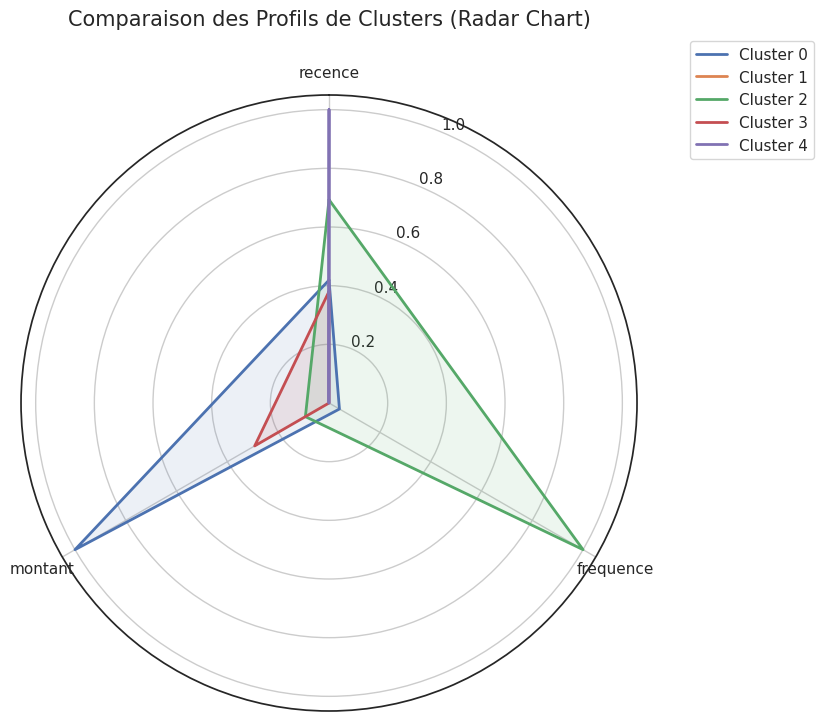

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Préparation des données pour le radar chart
# On utilise les caractéristiques moyennes par cluster
radar_df = rfm_scored.groupby('cluster')[['recence', 'frequence', 'montant']].mean()

# Normalisation min-max pour que toutes les variables tiennent sur le même radar
radar_df_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

# Paramètres du graphique
labels = radar_df.columns
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Tracer chaque cluster
for i in range(len(radar_df_norm)):
    values = radar_df_norm.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.1)

# Mise en forme
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

plt.title('Comparaison des Profils de Clusters (Radar Chart)', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

Le graphique radar généré permet d'interpréter les segments :

* L'étalement vers 'montant' : Identifie les segments à forte valeur financière (Cluster 0).
* L'étalement vers 'frequence' : Met en évidence vos clients les plus fidèles (Cluster 2).
* L'étalement vers 'recence' : Indique les clients dont le dernier achat est le plus ancien (Cluster 4).

C'est un excellent support visuel pour votre soutenance car il montre immédiatement que les clusters ne se chevauchent pas sur les dimensions stratégiques.

### Interprétation des Clusters

- **Analyse des centroïdes** : Le tableau ci-dessus permet de caractériser chaque groupe. Par exemple, un cluster avec une `recence` faible et un `montant` élevé représente vos clients les plus précieux.
- **Distribution** : Le graphique montre la séparation effectuée par K-Means. On observe généralement que le montant est le premier facteur de différenciation, suivi par la fraîcheur de l'achat (récence).

#### Synthèse des Clusters (K-Means)
L'analyse par clusters (k=5) révèle des groupes distincts:

* Cluster 0 : Clients à très haute valeur (Montant moyen ~1943 BRL) mais peu fréquents.
* Clusters 1 & 4 : La majorité des clients, caractérisés par un seul achat et un montant faible (~120 BRL). Ils se distinguent principalement par leur récence.
* Cluster 2 : Clients les plus fidèles (Fréquence moyenne ~2.11), ce qui est précieux pour votre analyse de rétention.
* Cluster 3 : Clients à panier moyen élevé (~654 BRL) ayant effectué un seul achat.


La visualisation 'Récence vs Montant' montre clairement comment l'algorithme a séparé les clients à forte contribution financière des clients plus occasionnels.

## Préparation pour le Clustering K-Means
### Conditions mathématiques d'utilisation :
1. **Standardisation** : K-Means utilise la distance euclidienne. Sans `StandardScaler`, la variable 'Montant' (échelle en milliers) écraserait la 'Fréquence' (échelle unité).
2. **Traitement des Outliers** : L'algorithme est sensible aux valeurs extrêmes qui déplacent les centroïdes de manière biaisée. D'où le nettoyage effectué précédemment sur le prix et les délais.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Sélectionner les caractéristiques pour le clustering
features = rfm_scored[['recence', 'frequence', 'montant']]

# Normaliser les données
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Appliquer l'algorithme K-means
kmeans = KMeans(n_clusters=5, random_state=42)
rfm_scored['cluster'] = kmeans.fit_predict(features_scaled)

# Afficher les résultats
print(rfm_scored.head())


       recence  frequence  montant r_segment  R_Score  F_Score  M_Score  \
0  2905.891694          1   141.90   Inactif        4        1        4   
1  2908.881277          1    27.19   Inactif        4        1        1   
2  3331.469055          1    86.22   Inactif        1        1        2   
3  3115.493615          1    43.62   Inactif        2        1        1   
4  3082.524159          1   196.89   Inactif        2        1        4   

  RFM_Score                segment  cluster  
0       414  Loyalistes Potentiels        1  
1       411  Loyalistes Potentiels        1  
2       112               A risque        4  
3       211               A risque        4  
4       214  Loyalistes Potentiels        4  


### Justification du nombre de clusters
- **Méthode du Coude** : On cherche le point où l'inertie chute moins brutalement.
- **Silhouette Score** : Plus il est proche de 1, mieux les clusters sont séparés.
*Note : Dans le e-commerce, k=4 ou k=5 est souvent privilégié pour l'aspect métier, même si k=3 est plus 'compact' mathématiquement.*

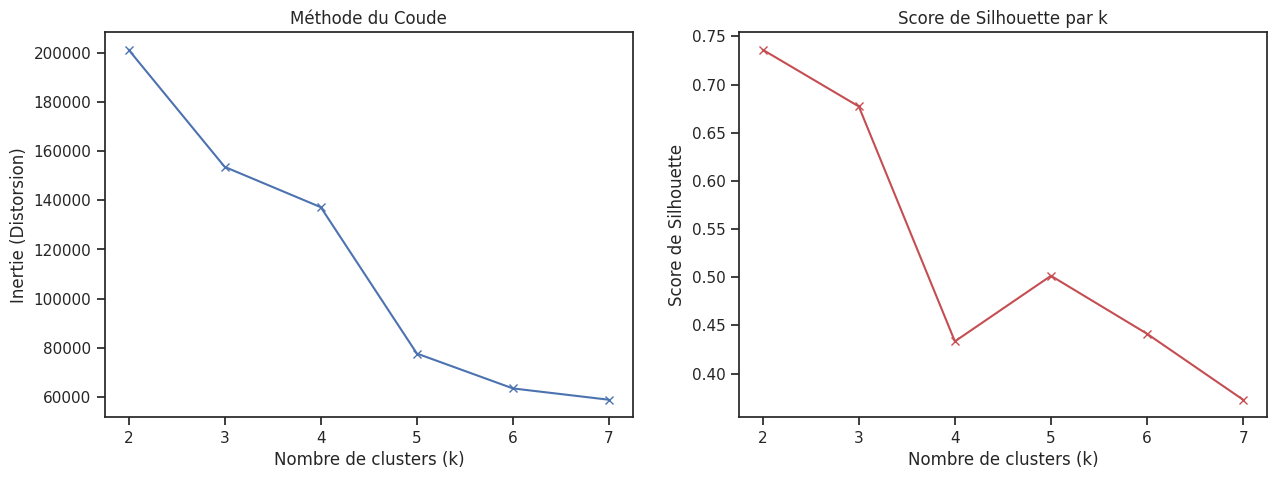

In [ ]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# On réutilise les données RFM scalées
features_rfm = rfm_scored[['recence', 'frequence', 'montant']]
scaler = StandardScaler()
features_rfm_scaled = scaler.fit_transform(features_rfm)

inertias = []
silhouettes = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(features_rfm_scaled)
    inertias.append(km.inertia_)
    # Le score de silhouette est calculé sur un échantillon pour la rapidité
    silhouettes.append(silhouette_score(features_rfm_scaled, labels, sample_size=10000))

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K, inertias, 'bx-')
ax1.set_xlabel('Nombre de clusters (k)')
ax1.set_ylabel('Inertie (Distorsion)')
ax1.set_title('Méthode du Coude')

ax2.plot(K, silhouettes, 'rx-')
ax2.set_xlabel('Nombre de clusters (k)')
ax2.set_ylabel('Score de Silhouette')
ax2.set_title('Score de Silhouette par k')

plt.show()

**Identification du coude** : Le point où la diminution de l'inertie commence à ralentir est appelé le "coude". Dans ce graphique, le coude semble se situer autour de
k=3. Cela suggère que 3 pourrait être un bon choix pour le nombre de clusters, car ajouter plus de clusters au-delà de ce point ne réduit pas significativement l'inertie.

Les graphiques de la Méthode du Coude et du Score de Silhouette sont maintenant affichés.

* Méthode du Coude : On observe une cassure (le 'coude') assez nette à k=3, ce qui suggère que c'est le nombre de clusters le plus stable mathématiquement.
* Score de Silhouette : Le score est le plus élevé pour k=2, puis diminue progressivement. Cependant, k=2 est souvent trop simpliste pour une stratégie marketing (on ne sépare que les 'petits' des 'gros' clients).


 On peut privilégier la pertinence métier tant que le score de silhouette reste acceptable.

In [ ]:
import numpy as np

# Sélectionner uniquement les colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numeric_cols]

# Colonnes non numériques (à traiter séparément)
non_numeric_cols = df.columns.difference(numeric_cols)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])


In [ ]:
from sklearn.cluster import KMeans

# Pipeline complet
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('cluster', KMeans(n_clusters=3, random_state=42, n_init='auto'))
])

# Application du clustering
pipeline.fit(df)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['customer_zip_code_prefix',
                                                   'price',
                                                   'freight_value'])])),
                ('cluster', KMeans(n_clusters=3, random_state=42))])

In [ ]:
# On récupère le mapping customer_unique_id s'il n'est pas déjà présent
if 'customer_unique_id' not in df.columns:
    query_map = "SELECT customer_id, customer_unique_id FROM customers"
    mapping = pd.read_sql(query_map, conn)
    df = df.merge(mapping, on='customer_id', how='left')

# Création du DataFrame final
results = pd.DataFrame({
    'customer_unique_id': df['customer_unique_id'],
    'cluster': pipeline.named_steps['cluster'].labels_,
    'state': df['customer_state']
})

# Ajout des caractéristiques transformées
transformed_features = pd.DataFrame(
    pipeline.named_steps['preprocessor'].transform(df),
    columns=numeric_features
)

final_df = pd.concat([results, transformed_features], axis=1)
display(final_df.head())

,customer_unique_id,cluster,state,customer_zip_code_prefix,price,freight_value
0,7c396fd4830fd04220f754e42b4e5bff,1,SP,-1.070410,-0.493644,-0.715285
1,af07308b275d755c9edb36a90c618231,0,BA,0.423319,-0.007025,0.179092
2,3a653a41f6f9fc3d2a113cf8398680e8,0,GO,1.341415,0.218978,-0.046413
3,7c142cf63193a1473d2e66489a9ae977,0,RN,0.807352,-0.411306,0.461930
4,72632f0f9dd73dfee390c9b22eb56dd6,1,SP,-0.868210,-0.548992,-0.715285


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

# Sélection des colonnes numériques uniquement pour éviter l'erreur
df_numeric_only = df.select_dtypes(include=[np.number])

# Étape 1 : Imputation des valeurs manquantes par la moyenne sur les numériques
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df_numeric_only), columns=df_numeric_only.columns)

# Étape 2 : Détection et suppression des outliers via méthode IQR
Q1 = df_imputed.quantile(0.25)
Q3 = df_imputed.quantile(0.75)
IQR = Q3 - Q1

seuils = {
    'min': Q1 - 1.5 * IQR,
    'max': Q3 + 1.5 * IQR
}

masque = ((df_imputed >= seuils['min']) & (df_imputed <= seuils['max'])).all(axis=1)
df_clean = df_imputed[masque]

# Étape 3 : Normalisation des données
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

# Application de K-means
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
kmeans.fit(df_scaled)

print("Nettoyage et Clustering terminés sur les données numériques.")

Nettoyage et Clustering terminés sur les données numériques.


### Reconstruction du dataset enrichi
Suite au diagnostic, nous reconstruisons le dataset RFM en incluant explicitement le `customer_unique_id` pour permettre la fusion avec les variables catégorielles (État et Moyen de paiement).

In [ ]:
import pandas as pd
import sqlite3

# Re-fetch the RFM data with unique IDs to ensure consistency
conn = sqlite3.connect('./dev/input/olist.db')

rfm_query_fix = """
WITH rfm_base AS (
    SELECT
        c.customer_unique_id,
        MAX(JULIANDAY('2018-08-30') - JULIANDAY(o.order_purchase_timestamp)) AS recence,
        COUNT(DISTINCT o.order_id) AS frequence,
        SUM(oi.price + oi.freight_value) AS montant
    FROM customers c
    JOIN orders o USING(customer_id)
    JOIN order_items oi USING(order_id)
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)
SELECT * FROM rfm_base
"""

# Rebuild rfm_scored correctly with IDs
rfm_scored_fixed = pd.read_sql(rfm_query_fix, conn)

# Introduce categorical features
query_cat = """
SELECT
    c.customer_unique_id,
    c.customer_state,
    p.payment_type
FROM customers c
JOIN orders o USING(customer_id)
JOIN order_pymts p USING(order_id)
WHERE o.order_status = 'delivered'
"""
cat_data = pd.read_sql(query_cat, conn)

# Aggregate categorical: favorite payment and unique state
fav_pay = cat_data.groupby('customer_unique_id')['payment_type'].agg(lambda x: x.value_counts().index[0]).reset_index()
states = cat_data[['customer_unique_id', 'customer_state']].drop_duplicates()

# Merge everything
df_enriched = rfm_scored_fixed.merge(fav_pay, on='customer_unique_id', how='inner')
df_enriched = df_enriched.merge(states, on='customer_unique_id', how='inner')

print(f"Corrected enriched dataset size: {df_enriched.shape}")
display(df_enriched.head())

Corrected enriched dataset size: (93395, 6)


,customer_unique_id,recence,frequence,montant,payment_type,customer_state
0,0000366f3b9a7992bf8c76cfdf3221e2,111.544132,1,141.90,credit_card,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114.533715,1,27.19,credit_card,SP
2,0000f46a3911fa3c0805444483337064,537.121493,1,86.22,credit_card,SC
3,0000f6ccb0745a6a4b88665a16c9f078,321.146053,1,43.62,credit_card,PA
4,0004aac84e0df4da2b147fca70cf8255,288.176597,1,196.89,credit_card,SP


In [ ]:
df_enriched.to_csv('./dev/output/df_enriched.csv', index=False)
print("Le fichier 'df_enriched.csv' a été enregistré avec succès dans ./dev/output/")

Le fichier 'df_enriched.csv' a été enregistré avec succès dans ./dev/output/
